In [2]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
from corsikaio import CorsikaParticleFile
import pandas as pd
import random
import os

In [33]:
run = 0
primary ='proton'
energy = 'lgE_17.0'
sin2theta = '0.4'

file_path = (f'/data/sim/IceCubeUpgrade/CosmicRay/Radio/coreas/data/continuous/star-pattern/{primary}/{energy}/sin2_{sin2theta}/{run:06d}/DAT{run:06d}')
file_input = (f"/data/sim/IceCubeUpgrade/CosmicRay/Radio/coreas/data/continuous/star-pattern/{primary}/{energy}/sin2_{sin2theta}/{run:06d}/SIM{run:06d}.inp")


# kinetic energy 
def Ekin(px,py,pz,m):
    return np.sqrt(px**2 + py**2 + pz**2 + m**2) -m 

def R(x,y):
    return np.sqrt(x**2 + y**2)
# constants
mumass = 0.105658 #muon mass in GeV/c^2
emass = 5.11e-4 #electron mass in GeV/c^2


with open(file_input) as f:
	for line in f:
		parts = line.split()
		if parts[0] == "THETAP":
			thetap = float(parts[1]) # zenith angle (deg)
		if parts[0] == "ERANGE": 
			primE = float(parts[1]) # energy of primary particle (GeV)



with CorsikaParticleFile(file_path, thinning= True) as file:
	# we only have one event per file, we can grab it like this
	event = next(file)


# get the particle info
#print(event.particles.dtype.names)
particle_id = event.particles['particle_description'] // 1000 # corsika particle ID
x = event.particles['x'] # x coordinate
y = event.particles['y'] # y coordinate
px = event.particles['px'] # momentum component in x direction in GeV
py = event.particles['py'] # momentum component in y direction in GeV
pz = event.particles['pz'] # momentum component in z direction in GeV
weight = event.particles['thinning_weight'] # particle weight 


# get indices of muons
idx_mu = np.where((particle_id == 5) | (particle_id == 6))
idx_epm = np.where((particle_id == 2) | (particle_id == 3))
idx_electron = np.where((particle_id == 3))

# particle position
x_mu, y_mu = x[idx_mu], y[idx_mu]
x_epm, y_epm = x[idx_epm], y[idx_epm]
x_e, y_e = x[idx_electron], y[idx_electron]

R_mu = R(x_mu, y_mu) 
R_epm = R(x_epm, y_epm)
R_e = R(x_e, y_e)

mask_mu = (R_mu > 200e3) # unit in cm
mask_epm = (R_epm > 200e3) # unit in cm 
mask_e = (R_e > 200e3) # unit in cm 

# Kinetic energy in GeV
Ek_mu = Ekin(px[idx_mu], py[idx_mu], pz[idx_mu], mumass)
Ek_epm = Ekin(px[idx_epm], py[idx_epm], pz[idx_epm], emass) 
Ek_electron = Ekin(px[idx_electron], py[idx_electron], pz[idx_electron], emass) 

Ek_mu = Ek_mu[mask_mu]
Ek_epm = Ek_epm[mask_epm]
Ek_e = Ek_electron[mask_e]

weight_mu = weight[idx_mu][mask_mu]
weight_epm = weight[idx_epm][mask_epm]
weight_e = weight[idx_electron][mask_e]

# Define array of particle types
Ek_array = [Ek_e, Ek_mu]
weight_array = [weight_e, weight_mu]

In [34]:
print(len(Ek_array[0]), len(weight_array[0]))

2985 2985


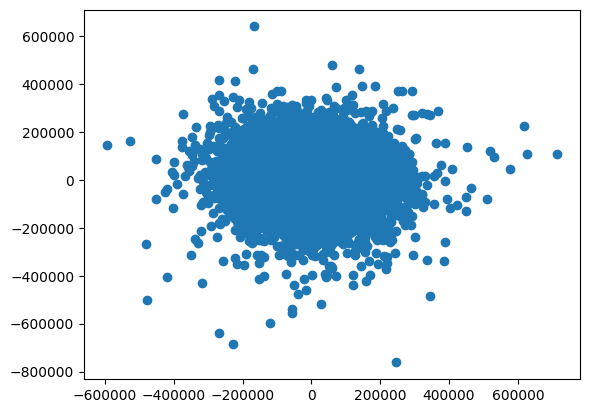

In [6]:
plt.scatter(x_mu,y_mu)